<a href="https://colab.research.google.com/github/roxaaaaa/Predictive-Analytics/blob/main/ca1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CA1: Predictive Regression Modelling Assignment

Student Name : Roksolana Kryvulia

Student L Number : L00188404

Tasks for Regressio (copied from assignement overview):
1. Download or use the assigned unique dataset to will allow you to perform predictive analysis.
2. Exploratory Data Analysis: Explore the data and its features and any other statistical measure to
assist in the prediction analysis. Discuss any data observations that may impact the models.
3. Perform any cleaning and data preparation if required. Discuss and explain why the particular
cleaning and data preparation was used.
4. Identify the prediction that may be made after the data analysis
5. Perform:
*   Linear Regression
*   Multiple Linear Regression
*   Polynomial Regression Model
*   Logistic Regression
6. The student should have more than one model for each regression type.
a. E.g. for Linear Regression perform the regression, review and explain the metrics.
Why does the metrics give the value it has and was this expected after performing
the exploratory data analysis.
b. Identify another independent variable to use and perform at least 1 other regression
analysis, explain why this variable was chosen, review and explain the metrics and
compare to the first model.

7. Discuss and explain what the metric results indicate. A student must use a combination of metrics
will indicate whether a model is a good fit or not. Knowing why a model is/is not a good fit is
required.
8. Provide explanation as to why the particular library was chosen. The student must take into
consideration that multiple python libraries can be used. Using more than one library and
providing comparison of the models is recommended.


In [1]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

The UCI fetcher automatically splits features and targets into two separate dataframes (X and y).

After some time trying to figure it out(align X and Y indexed, add columns to X then drop them later, keep track of which target to use for which model),I decided to merge it in one dataframe.

In [3]:
df = wine_quality.data.features.copy()
df['quality'] = wine_quality.data.targets['quality'].values

In [4]:
display(df.describe())

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


residual_sugar usually stays below about 8.1 (75%).
But the maximum is 65.8, which is extremely high. That means there are some unusual wines with very high sugar that could skew the model.

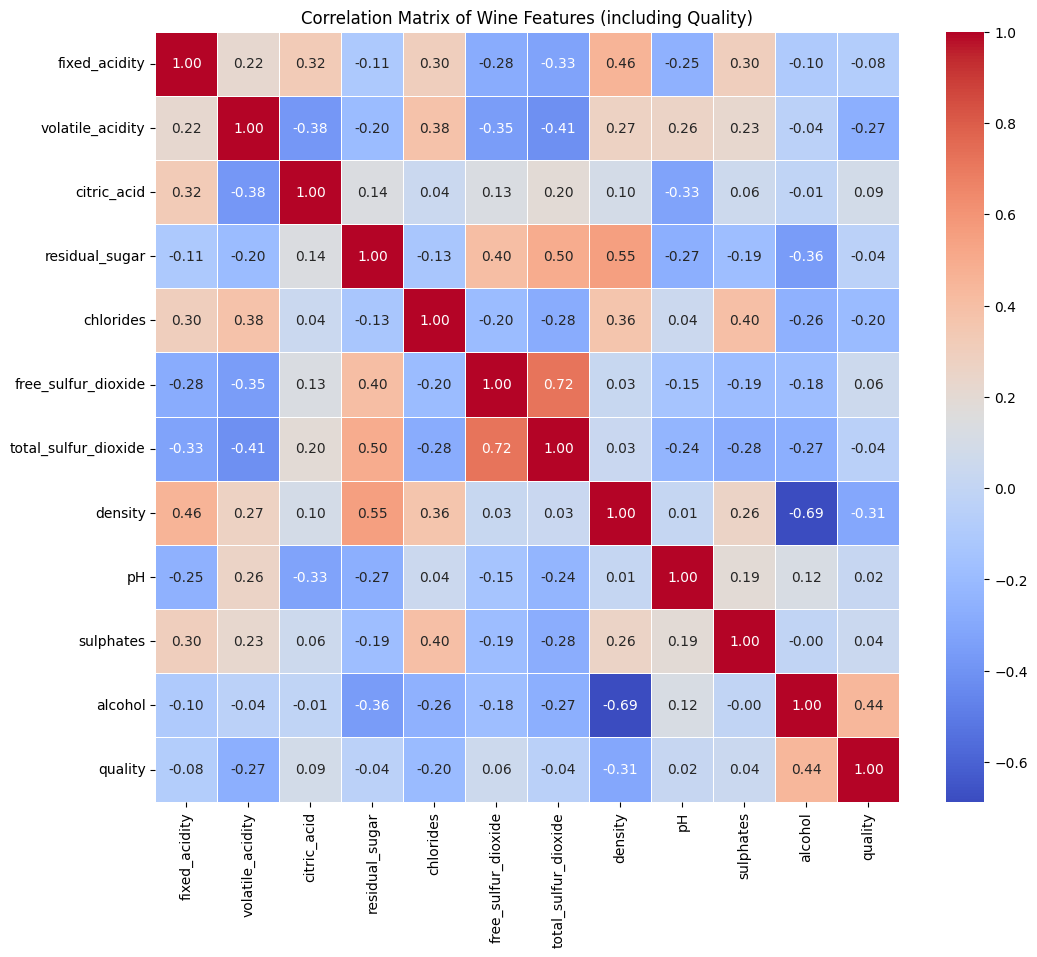

In [5]:
# Calculate the correlation matrix (including quality)
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Wine Features (including Quality)')
plt.show()

# TOP 3 BASED ON QUALITY

**Alcohol and Quality - strong positive correlation** *0.44*
When alcohol increases, quality increases.

**Density and Quality - negative correlation** *-0.31*

**Volatility Acid and Quality - negative correlation** *-0.27*

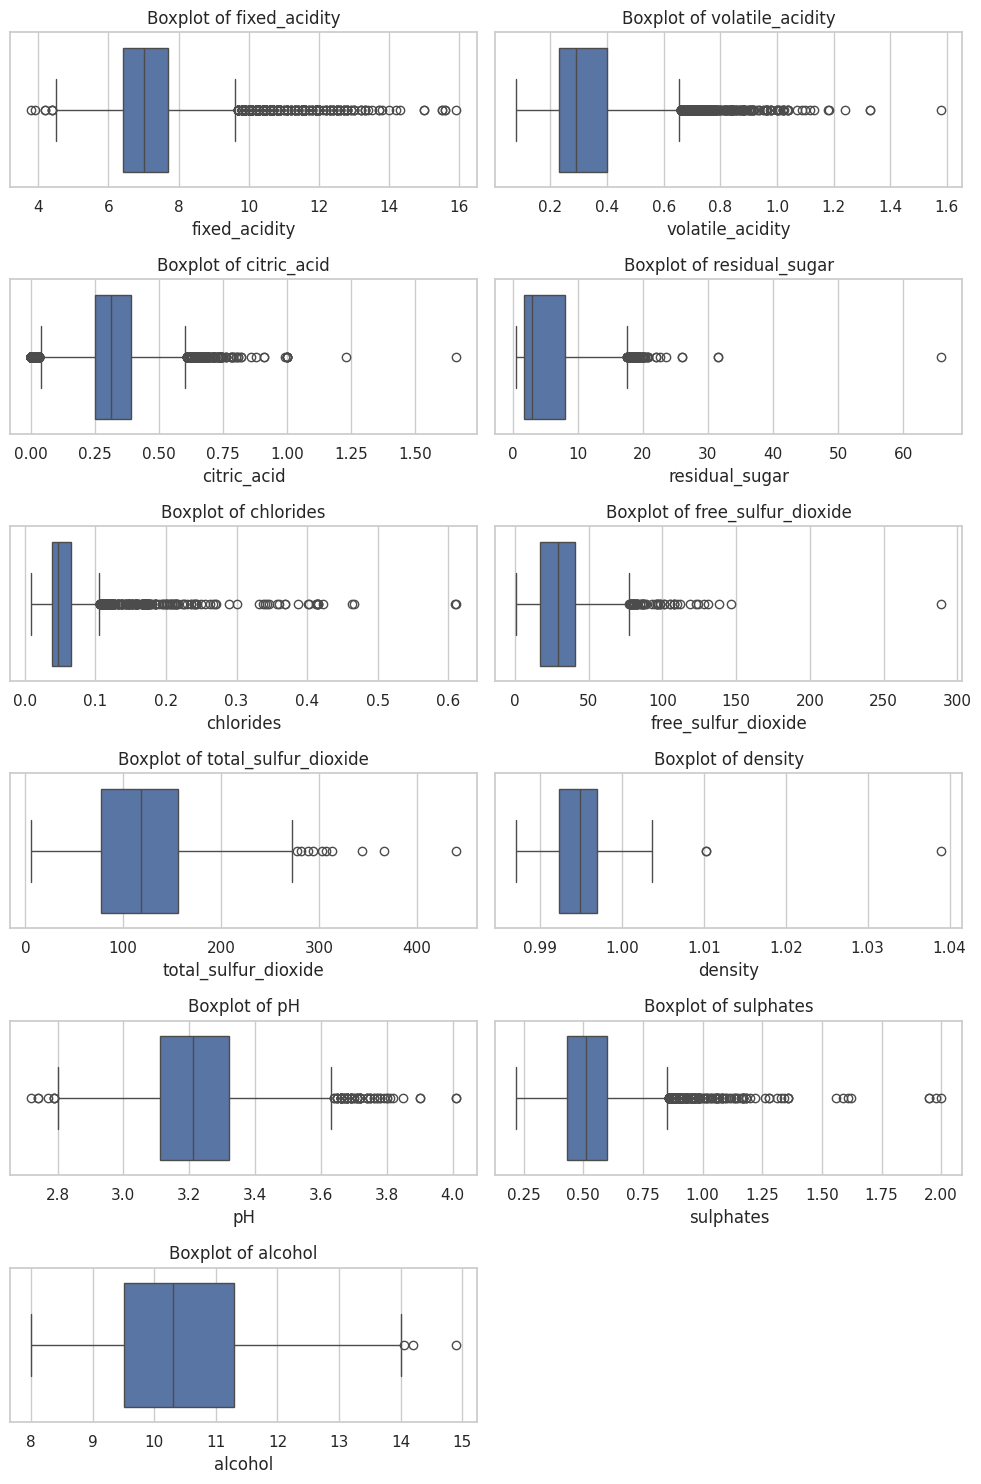

In [6]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 15))
features = df.drop(columns=['quality']).columns

for i, col in enumerate(features):
    plt.subplot(6, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Strongly right skewed outliners

I clean all features because later they will be used in Multiple Regression and Logistic Regression models

In [7]:
for i in ["residual_sugar", "chlorides", "volatile_acidity",
          "fixed_acidity", "citric_acid", "free_sulfur_dioxide",
          "total_sulfur_dioxide", "sulphates", "pH", "density", "alcohol"]:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    df = df[df[i] <= upper]

print(f"Rows remaining after cleaning: {len(df)}")

Rows remaining after cleaning: 5093


IQR-based filtering was applied to remove extreme outliers from all features.

The Interquartile Range is a statistical method used to find and remove outliers from a dataset. It measures the spread of the middle 50% of the data by calculating the difference between the 25th percentile (Q1) and the 75th percentile (Q3). Any value higher than Q3 + 1.5 × IQR is treated as an outlier and removed. This method was chosen because it works well with skewed data and does not require a normal distribution. Removing outliers helps prevent extreme values from having a disproportionate impact on model coefficients.

This makes it suitable for the wine chemical properties because of strong right skewness of its features.


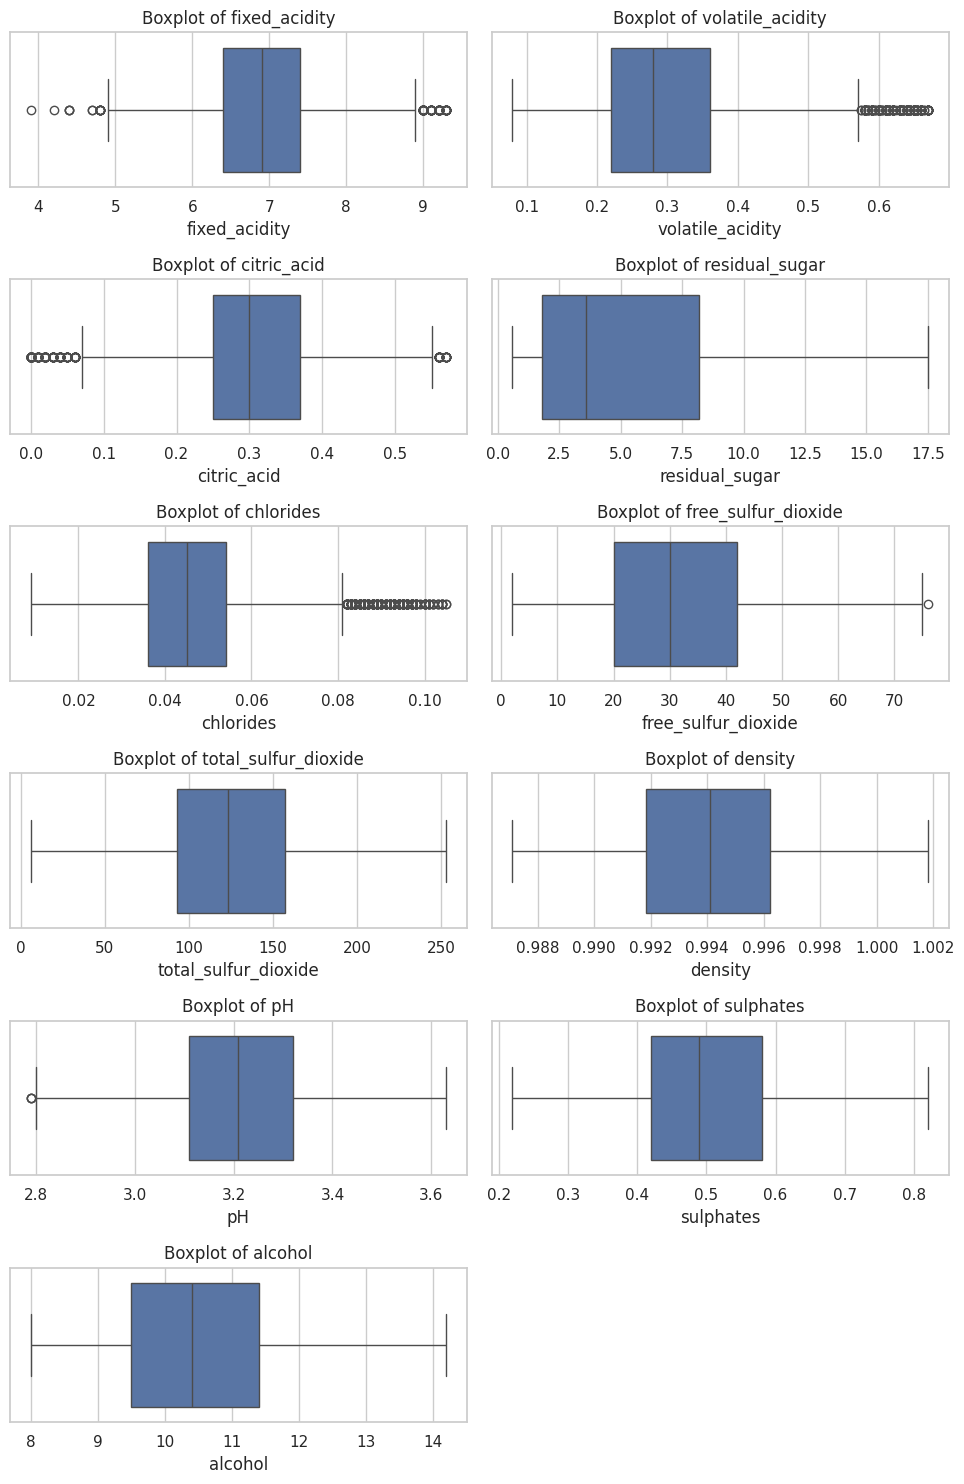

In [8]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 15))
features = df.drop(columns=['quality']).columns

for i, col in enumerate(features):
    plt.subplot(6, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [23]:
df['high_quality'] = [1 if x >= 7 else 0 for x in df['quality']]

print(df['high_quality'].value_counts())
print(df['high_quality'].value_counts(normalize=True) * 100)

high_quality
0    4002
1    1091
Name: count, dtype: int64
high_quality
0    78.578441
1    21.421559
Name: proportion, dtype: float64


distribution is 78.6% / 21.4%.

wines with a quality score of 7 or higher are labeled as 1 (premium quality), and those with scores below 7 are labeled as 0. The output shows that out of the total wines in the dataset, only 1091 wines are classified as high-quality, while the majority 4002 wines are the lower quality category. This reveals a significant class imbalance in the dataset.

In [10]:
# Define features and targets
X = df.drop(columns=['quality', 'high_quality'])
y_regression = df['quality']
y_classification = df['high_quality']

In [11]:
from sklearn.model_selection import train_test_split

# For Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)

# For Logistic Regression
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_classification, test_size=0.2, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Regression
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
X_train_cls_scaled = scaler.fit_transform(X_train_cls)
X_test_cls_scaled = scaler.transform(X_test_cls)

In [13]:
print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (4074, 11)
Test set: (1019, 11)


11 columns = 11 wine features (after dropping quality and high_quality)

approximately an 80/20 train-test split(total 5093 = 4002 + 1091)



# Model 1: Linear Regression Alcohol vs Quality

I chosed Alcohol as the independent variable for the first linear regression model because it has the strongest and most direct relationship with wine quality. Wines with higher alcohol content tend to receive better quality ratings.

R² Score : 0.2024
MAE      : 0.6027
MSE      : 0.5724
RMSE     : 0.7566
Statsmodels: Linear Regression Model 1 - Alcohol
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     948.2
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          2.24e-187
Time:                        23:44:37   Log-Likelihood:                -4786.0
No. Observations:                4074   AIC:                             9576.
Df Residuals:                    4072   BIC:                             9589.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------

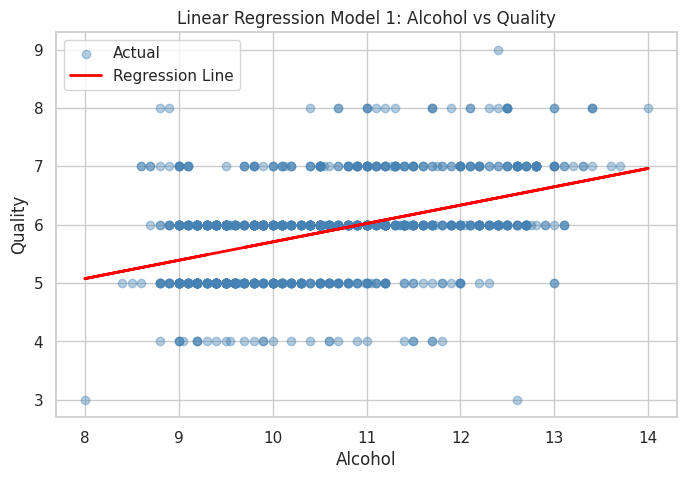

In [24]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Linear Regression Model 1: Alcohol vs Quality

X_train_lr = X_train[["alcohol"]]
X_test_lr = X_test[["alcohol"]]

lr_model1 = LinearRegression()
lr_model1.fit(X_train_lr, y_train)
y_pred_lr1 = lr_model1.predict(X_test_lr)

r2 = r2_score(y_test, y_pred_lr1)
mse = mean_squared_error(y_test, y_pred_lr1)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lr1)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")


X_train_lr_sm = sm.add_constant(X_train_lr)
sm_model1 = sm.OLS(y_train, X_train_lr_sm).fit()
print("Statsmodels: Linear Regression Model 1 - Alcohol")
print(sm_model1.summary())

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_test_lr, y_test, color="steelblue", alpha=0.4, label="Actual")
plt.plot(X_test_lr, y_pred_lr1, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Linear Regression Model 1: Alcohol vs Quality")
plt.legend()
plt.show()

Alcohol explains about 20% of why wine quality varies. The other 80% comes from other factors. MAE: 0.6027 - The model's predictions are off by about 0.6 quality points on average.Alcohol coefficient: 0.315 - When alcohol goes up by 1%, quality goes up by about 0.3 points.

So higher alcohol means higher quality, but alcohol alone cannot tell the whole story. Other things like acidity and density also matter for wine quality.

# Model 2: DENSITY vs Quality
Desity is the second strongest correlation in the dataset.



Scikit-learn: Linear Regression Model 2 - Density ===
R² Score : 0.1144
MAE      : 0.6252
MSE      : 0.6356
RMSE     : 0.7972
Statsmodels: Linear Regression Model 2 - Density
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     412.3
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           2.12e-87
Time:                        23:49:12   Log-Likelihood:                -5016.0
No. Observations:                4074   AIC:                         1.004e+04
Df Residuals:                    4072   BIC:                         1.005e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err   

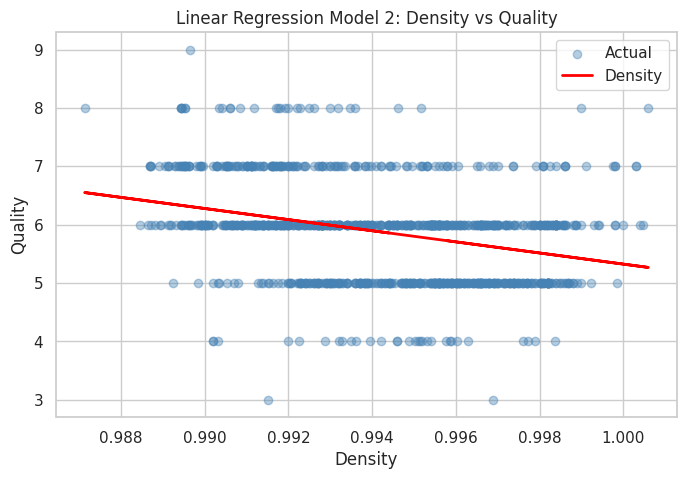

In [25]:
# Linear Regression Model 2:Density vs Quality ----

X_train_lr2 = X_train[["density"]]
X_test_lr2 = X_test[["density"]]

lr_model2 = LinearRegression()
lr_model2.fit(X_train_lr2, y_train)
y_pred_lr2 = lr_model2.predict(X_test_lr2)

r2_2 = r2_score(y_test, y_pred_lr2)
mse_2 = mean_squared_error(y_test, y_pred_lr2)
rmse_2 = np.sqrt(mse_2)
mae_2 = mean_absolute_error(y_test, y_pred_lr2)

print("Scikit-learn: Linear Regression Model 2 - Density ===")
print(f"R² Score : {r2_2:.4f}")
print(f"MAE      : {mae_2:.4f}")
print(f"MSE      : {mse_2:.4f}")
print(f"RMSE     : {rmse_2:.4f}")

X_train_lr2_sm = sm.add_constant(X_train_lr2)
sm_model2 = sm.OLS(y_train, X_train_lr2_sm).fit()
print("Statsmodels: Linear Regression Model 2 - Density")
print(sm_model2.summary())

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_test_lr2, y_test, color="steelblue", alpha=0.4, label="Actual")
plt.plot(X_test_lr2, y_pred_lr2, color="red", linewidth=2, label="Density")
plt.xlabel("Density")
plt.ylabel("Quality")
plt.title("Linear Regression Model 2: Density vs Quality")
plt.legend()
plt.show()

Density explains only about 11% of why wine quality varies. This is weaker than alcohol (which explained 20%).
Density coefficient: -95.29 (p < 0.001) - This negative value confirms that lower density wines get higher quality ratings.
R-squared: 0.092 from Statsmodels - Very close to the test result, showing the model is stable.  it has slightly larger prediction errors


In [26]:
# Multiple Regression Model 1: All Features
# Using all 11 chemical features to predict quality.
# This tests whether combining all available information improves prediction over a single feature.

lr_multi1 = LinearRegression()
lr_multi1.fit(X_train_scaled, y_train)
y_pred_multi1 = lr_multi1.predict(X_test_scaled)

r2_m1 = r2_score(y_test, y_pred_multi1)
mse_m1 = mean_squared_error(y_test, y_pred_multi1)
rmse_m1 = np.sqrt(mse_m1)
mae_m1 = mean_absolute_error(y_test, y_pred_multi1)

print("Scikit-learn: Multiple Regression Model 1 - All Features")
print(f"R² Score : {r2_m1:.4f}")
print(f"MAE      : {mae_m1:.4f}")
print(f"MSE      : {mse_m1:.4f}")
print(f"RMSE     : {rmse_m1:.4f}")

# Statsmodels
X_train_sm_all = sm.add_constant(X_train_scaled)
sm_multi1 = sm.OLS(y_train, X_train_sm_all).fit()
print("Statsmodels: Multiple Regression Model 1 - All Features")
print(sm_multi1.summary())

Scikit-learn: Multiple Regression Model 1 - All Features
R² Score : 0.2751
MAE      : 0.5589
MSE      : 0.5202
RMSE     : 0.7213
Statsmodels: Multiple Regression Model 1 - All Features
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     140.9
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          3.78e-275
Time:                        23:52:02   Log-Likelihood:                -4554.1
No. Observations:                4074   AIC:                             9132.
Df Residuals:                    4062   BIC:                             9208.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    

0.2751 - All features together explain about 27.5% of why wine quality varies. This is better than using alcohol alone (20%) or density alone (11%).

MAE: 0.5589 - Predictions are off by about 0.56 quality points on average. This is the smallest error so far.

RMSE: 0.7213 - Also the lowest error among all models.

best predictions so far

In [27]:
# Multiple Regression Model 2: Selected Features top 3

selected_features = ["alcohol", "volatile_acidity", "density"]

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

scaler2 = StandardScaler()
X_train_sel_scaled = scaler2.fit_transform(X_train_sel)
X_test_sel_scaled = scaler2.transform(X_test_sel)

lr_multi2 = LinearRegression()
lr_multi2.fit(X_train_sel_scaled, y_train)
y_pred_multi2 = lr_multi2.predict(X_test_sel_scaled)

r2_m2 = r2_score(y_test, y_pred_multi2)
mse_m2 = mean_squared_error(y_test, y_pred_multi2)
rmse_m2 = np.sqrt(mse_m2)
mae_m2 = mean_absolute_error(y_test, y_pred_multi2)

print("Scikit-learn: Multiple Regression Model 2")
print(f"R² Score : {r2_m2:.4f}")
print(f"MAE      : {mae_m2:.4f}")
print(f"MSE      : {mse_m2:.4f}")
print(f"RMSE     : {rmse_m2:.4f}")

# Statsmodels
X_train_sel_sm = sm.add_constant(X_train_sel_scaled)
sm_multi2 = sm.OLS(y_train, X_train_sel_sm).fit()
print("Statsmodels: Multiple Regression Model 2 - Selected Feature")
print(sm_multi2.summary())

Scikit-learn: Multiple Regression Model 2
R² Score : 0.2439
MAE      : 0.5785
MSE      : 0.5426
RMSE     : 0.7366
Statsmodels: Multiple Regression Model 2 - Selected Feature
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     441.3
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          3.09e-248
Time:                        23:54:22   Log-Likelihood:                -4638.8
No. Observations:                4074   AIC:                             9286.
Df Residuals:                    4070   BIC:                             9311.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err    

All 3 selected features are highly significant (p < 0.001)

Using just 3 features gives much better results than using alcohol or density alone

The full model with all 11 features is only slightly better (about 3% more R square) than the 3 feature model



In [28]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
import statsmodels.api as sm

#Polynomial Regression Model 1: Alcohol (degree 2)
# Alcohol was chosen again to test whether a curved (non-linear) relationship

X_train_poly1 = X_train[["alcohol"]]
X_test_poly1 = X_test[["alcohol"]]

pr = PolynomialFeatures(degree=2)
X_train_poly1_tr = pr.fit_transform(X_train_poly1)
X_test_poly1_tr = pr.transform(X_test_poly1)


poly_model1 = linear_model.LinearRegression()
poly_model1.fit(X_train_poly1_tr, y_train)
y_pred_poly1 = poly_model1.predict(X_test_poly1_tr)

r2_p1 = r2_score(y_test, y_pred_poly1)
mse_p1 = mean_squared_error(y_test, y_pred_poly1)
rmse_p1 = np.sqrt(mse_p1)
mae_p1 = mean_absolute_error(y_test, y_pred_poly1)

print("Scikit-learn: Polynomial Regression Model 1 - Alcohol (degree 2)")
print(f"R² Score : {r2_p1:.4f}")
print(f"MAE      : {mae_p1:.4f}")
print(f"MSE      : {mse_p1:.4f}")
print(f"RMSE     : {rmse_p1:.4f}")

# Statsmodels
X_train_poly1_sm = sm.add_constant(X_train_poly1_tr)
sm_poly1 = sm.OLS(y_train, X_train_poly1_sm).fit()
print("Statsmodels: Polynomial Regression Model 1 - Alcohol (degree 2)")
print(sm_poly1.summary())

Scikit-learn: Polynomial Regression Model 1 - Alcohol (degree 2)
R² Score : 0.2047
MAE      : 0.6040
MSE      : 0.5708
RMSE     : 0.7555
Statsmodels: Polynomial Regression Model 1 - Alcohol (degree 2)
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     484.7
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          1.47e-189
Time:                        23:56:09   Log-Likelihood:                -4777.3
No. Observations:                4074   AIC:                             9561.
Df Residuals:                    4071   BIC:                             9580.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
         

Adding a curved line does not improve predictions much. The relationship between alcohol and quality is mostly straight-line (linear). The small gain (0.2%) is not worth the extra complexity. This confirms that a simple straight line is good enough to understand how alcohol affects wine quality.

In [29]:
# Polynomial Regression Model 2: Alcohol + Volatile Acidity (degree 2) ----

X_train_poly2 = X_train[["alcohol", "density"]]
X_test_poly2 = X_test[["alcohol", "density"]]

pr2 = PolynomialFeatures(degree=2)
X_train_poly2_tr = pr2.fit_transform(X_train_poly2)
X_test_poly2_tr = pr2.transform(X_test_poly2)

# Scikit-learn
poly_model2 = linear_model.LinearRegression()
poly_model2.fit(X_train_poly2_tr, y_train)
y_pred_poly2 = poly_model2.predict(X_test_poly2_tr)

r2_p2 = r2_score(y_test, y_pred_poly2)
mse_p2 = mean_squared_error(y_test, y_pred_poly2)
rmse_p2 = np.sqrt(mse_p2)
mae_p2 = mean_absolute_error(y_test, y_pred_poly2)

print("Scikit-learn: Polynomial Regression Model 2 - Alcohol + density (degree 2)")
print(f"R² Score : {r2_p2:.4f}")
print(f"MAE      : {mae_p2:.4f}")
print(f"MSE      : {mse_p2:.4f}")
print(f"RMSE     : {rmse_p2:.4f}")

# Statsmodels
X_train_poly2_sm = sm.add_constant(X_train_poly2_tr)
sm_poly2 = sm.OLS(y_train, X_train_poly2_sm).fit()
print("Statsmodels: Polynomial Regression Model 2 - Alcohol + density (degree 2) ===")
print(sm_poly2.summary())

Scikit-learn: Polynomial Regression Model 2 - Alcohol + density (degree 2)
R² Score : 0.2114
MAE      : 0.5997
MSE      : 0.5660
RMSE     : 0.7523
Statsmodels: Polynomial Regression Model 2 - Alcohol + density (degree 2) ===
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     205.6
Date:                Tue, 03 Mar 2026   Prob (F-statistic):          5.48e-196
Time:                        23:58:11   Log-Likelihood:                -4753.4
No. Observations:                4074   AIC:                             9519.
Df Residuals:                    4068   BIC:                             9557.
Df Model:                           5                                         
Covariance Type:            nonrobust                           

 0.2114 - This model explains about 21.1% of quality variation.

MAE: 0.5997 - Predictions are off by about 0.60 quality points on average.

RMSE: 0.7523 - The lowest error so far, but only slightly better.

The polynomial model with 2 features is only slightly better than using alcohol alone

The condition number is extremely large, which means there are major numerical problems

The simple linear models (especially the 3 feature model) are better in this case because they are simpler, more reliable, and actually perform better than this complex polynomial model. Adding curved terms for alcohol and density does not help much.



Logistic Regression Model 1 - All Features
Accuracy: 0.8135

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       819
           1       0.55      0.29      0.38       200

    accuracy                           0.81      1019
   macro avg       0.70      0.62      0.64      1019
weighted avg       0.79      0.81      0.79      1019



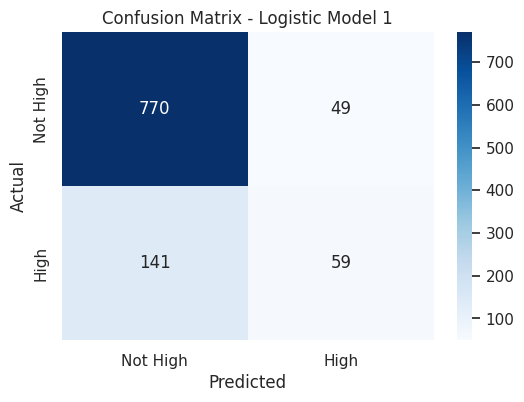

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Logistic Regression Model 1: all features

log_model1 = LogisticRegression(max_iter=1000)
log_model1.fit(X_train_cls_scaled, y_train_cls)

y_pred_log1 = log_model1.predict(X_test_cls_scaled)

print("Logistic Regression Model 1 - All Features")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_log1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_log1))

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_log1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High', 'High'],
            yticklabels=['Not High', 'High'])
plt.title('Confusion Matrix - Logistic Model 1')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The Problem: Class Imbalance
only 21.4% of wines are high-quality (1,091 out of 5,093). The model learns to just predict "not high-quality" most of the time because that's safe. This gives high accuracy (81%) but fails at its real job: finding the good wines.

The model looks accurate at first glance (81%), but it's actually not useful for identifying high quality wines. It misses most of them (71% missed) and makes many mistakes when it does try to find them. This is a common problem when one group is much smaller than the other.

Logistic Regression Model 2
Accuracy: 0.8077

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89       819
           1       0.52      0.23      0.32       200

    accuracy                           0.81      1019
   macro avg       0.68      0.59      0.61      1019
weighted avg       0.77      0.81      0.78      1019



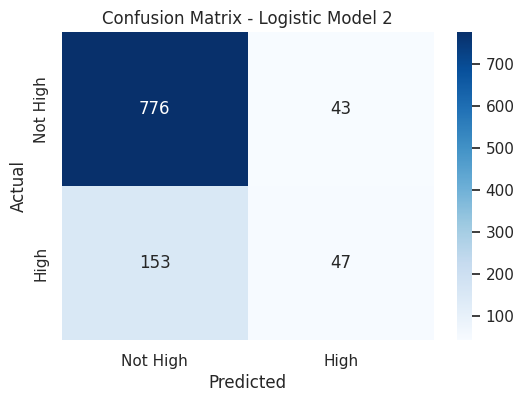

In [31]:
# Logistic Regression Model 2: selected features

selected_cls = ['alcohol', 'volatile_acidity', 'density']

X_train_cls2 = X_train[selected_cls]
X_test_cls2 = X_test[selected_cls]

scaler_cls2 = StandardScaler()
X_train_cls2_scaled = scaler_cls2.fit_transform(X_train_cls2)
X_test_cls2_scaled = scaler_cls2.transform(X_test_cls2)

log_model2 = LogisticRegression(max_iter=1000)
log_model2.fit(X_train_cls2_scaled, y_train_cls)

y_pred_log2 = log_model2.predict(X_test_cls2_scaled)

print("Logistic Regression Model 2")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_log2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_log2))

# Confusion Matrix
cm2 = confusion_matrix(y_test_cls, y_pred_log2)
plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High', 'High'],
            yticklabels=['Not High', 'High'])
plt.title('Confusion Matrix - Logistic Model 2')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Model 2 is slightly worse than Model 1 for finding high quality wines

 This model finds only 23% of actual high quality wines (worse than Model 1's 29%)

Precision 0.52 - When it says a wine is high quality, it's correct 52% of the time (slightly worse than 55%)

Both models have the same problem: they miss most high-quality wines

Using fewer features makes the model a bit worse, but not by much.

